In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from plot_generators.classes import contracting_star
import os 
os.environ["PATH"] += os.pathsep + '/Library/TeX/texbin'
sns.set_theme(font_scale=2, rc={'text.usetex' : True})
sns.set_style("whitegrid", {'axes.grid' : False})



In [2]:
def ellipse(a, b, x):
  return b/a * np.sqrt(a**2-(2*a*x-a)**2)

def transform_blade_point(x, y, d_theta):
  """Assuming no transformation already for the blade_point"""
  r = np.sqrt(x**2 + y**2)
  theta = np.arctan(y/x) if x != 0 else np.pi/2 if y > 0 else 3*np.pi/2
  p = (r*np.cos(theta + d_theta), r*np.sin(theta + d_theta))
  # print(np.sqrt(p[0]**2 + p[1]**2))
  return p

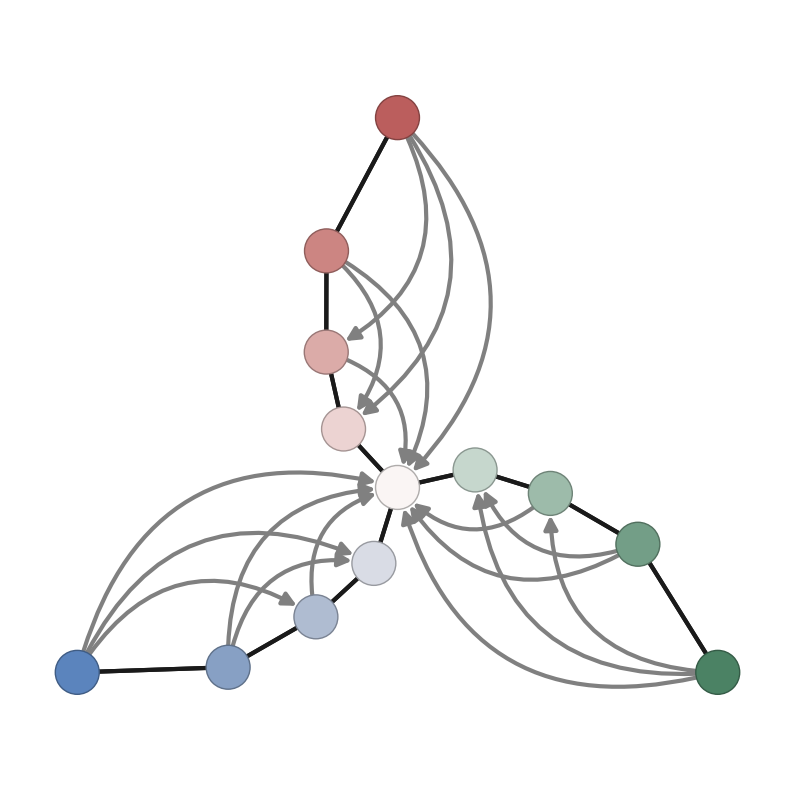

In [10]:
n = 13

n_blades = 3
G = contracting_star(n, n_blades)

# Node curve constants.
a, b = 3, .2

# Node position constant.
c = 3

xs = (c**np.linspace(0, 1, n//n_blades+1, endpoint=True)-1)/(c-1)
thetas = np.linspace(0, 2*np.pi, n_blades, endpoint=False)+(np.pi/2 if n_blades == 3 else 0)

fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')
ax.set_aspect('equal', adjustable='datalim')

pos = {
  node: ((0, 0) if node == str(n-1) else transform_blade_point(
    (x:=xs[1 + (n//n_blades-int(node[-1])-1)]),
    ellipse(a, b, x),
    thetas[int(node[1])],
  ))
  for node in G.nodes
}

nodesize=1000
cmap = sns.color_palette('vlag_r', n)
nodelist = list(sorted(G.nodes))
nodelist = nodelist[1:] + nodelist[:1]
reds = sns.color_palette('vlag_r', n_colors=1+2*(n//n_blades))
blues = sns.color_palette('vlag', n_colors=1+2*(n//n_blades))
greens = sns.diverging_palette(145, 300, s=60, n=1+2*(n//n_blades))
colors = {
  0: reds,
  1: blues,
  2: greens,
}
nodecolors = [
  colors[int(node[1])][int(node[-1])] if node != str(n-1) else blues[4]
  for node in nodelist
]
nx.draw_networkx_nodes(
  G,
  ax=ax,
  pos=pos,
  nodelist=nodelist,
  node_color=nodecolors,
  node_size=nodesize,
  edgecolors=[
    .7 * np.array(color) for color in nodecolors
  ],
)

undirected_edges = [
  (u, v)
  for (u, v) in G.edges
  if (u == str(n-1) and int(v[-1]) == 3) or (v == str(n-1) and int(u[-1]) == 3)
  or (u != str(n-1) and v != str(n-1) and u[1] == v[1] and abs(int(u[-1]) - int(v[-1]))==1)
]


nx.draw_networkx_edges(
  G,
  ax=ax,
  pos=pos,
  edgelist=undirected_edges,
  node_size=nodesize,
  width=3,
  arrows=False,
)

directed_edges = [edge for edge in G.edges if edge not in undirected_edges]
nx.draw_networkx_edges(
  G,
  ax=ax,
  pos=pos,
  edgelist=directed_edges,
  node_size=nodesize,
  width=3,
  arrows=True,
  arrowsize=20,
  connectionstyle="arc3,rad=-.5",
  edge_color='grey',
)
fig.savefig('./plots/contracting-star.eps', dpi=300, transparent=True)



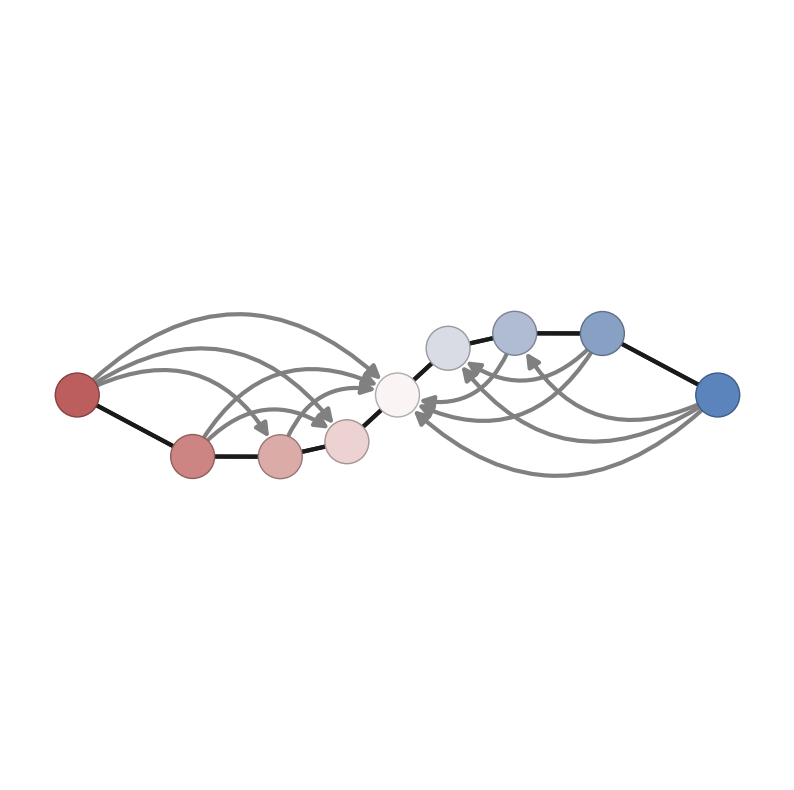

In [9]:
n = 9

n_blades = 2
G = contracting_star(n, n_blades)

# Node curve constants.
a, b = 3, .2

# Node position constant.
c = 3

xs = (c**np.linspace(0, 1, n//n_blades+1, endpoint=True)-1)/(c-1)
thetas = np.linspace(0, 2*np.pi, n_blades, endpoint=False)+(np.pi/2 if n_blades == 3 else 0)

fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')
ax.set_aspect('equal', adjustable='datalim')

pos = {
  node: ((0, 0) if node == str(n-1) else transform_blade_point(
    (x:=xs[1 + (n//n_blades-int(node[-1])-1)]),
    ellipse(a, b, x),
    thetas[int(node[1])],
  ))
  for node in G.nodes
}

nodesize=1000
cmap = sns.color_palette('vlag_r', n)
nodelist = list(sorted(G.nodes))
nodelist = nodelist[1:] + nodelist[:1]
reds = sns.color_palette('vlag_r', n_colors=1+2*(n//n_blades))
blues = sns.color_palette('vlag', n_colors=1+2*(n//n_blades))
greens = sns.diverging_palette(145, 300, s=60, n=1+2*(n//n_blades))
colors = {
  0: blues,
  1: reds,
  2: greens,
}
nodecolors = [
  colors[int(node[1])][int(node[-1])] if node != str(n-1) else blues[4]
  for node in nodelist
]
nx.draw_networkx_nodes(
  G,
  ax=ax,
  pos=pos,
  nodelist=nodelist,
  node_color=nodecolors,
  node_size=nodesize,
  edgecolors=[
    .7 * np.array(color) for color in nodecolors
  ],
)

undirected_edges = [
  (u, v)
  for (u, v) in G.edges
  if (u == str(n-1) and int(v[-1]) == 3) or (v == str(n-1) and int(u[-1]) == 3)
  or (u != str(n-1) and v != str(n-1) and u[1] == v[1] and abs(int(u[-1]) - int(v[-1]))==1)
]


nx.draw_networkx_edges(
  G,
  ax=ax,
  pos=pos,
  edgelist=undirected_edges,
  node_size=nodesize,
  width=3,
  arrows=False,
)

directed_edges = [edge for edge in G.edges if edge not in undirected_edges]
nx.draw_networkx_edges(
  G,
  ax=ax,
  pos=pos,
  edgelist=directed_edges,
  node_size=nodesize,
  width=3,
  arrows=True,
  arrowsize=20,
  connectionstyle="arc3,rad=-.5",
  edge_color='grey',
)
fig.savefig('./plots/contracting-path.eps', dpi=300, transparent=True)




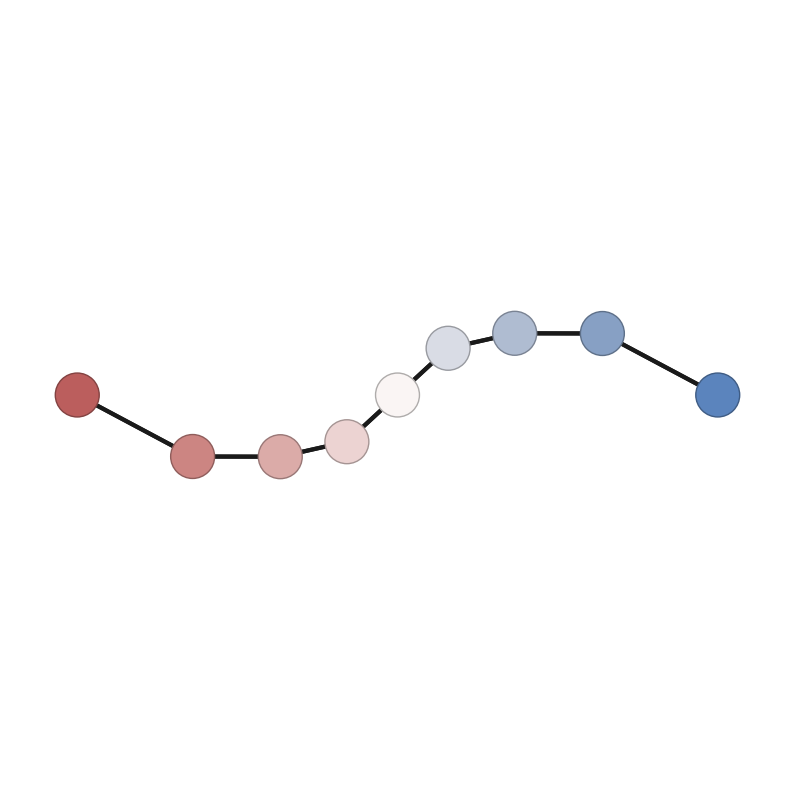

In [11]:
n = 9

n_blades = 2
G = contracting_star(n, n_blades)

# Node curve constants.
a, b = 3, .2

# Node position constant.
c = 3

xs = (c**np.linspace(0, 1, n//n_blades+1, endpoint=True)-1)/(c-1)
thetas = np.linspace(0, 2*np.pi, n_blades, endpoint=False)+(np.pi/2 if n_blades == 3 else 0)

fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')
ax.set_aspect('equal', adjustable='datalim')

pos = {
  node: ((0, 0) if node == str(n-1) else transform_blade_point(
    (x:=xs[1 + (n//n_blades-int(node[-1])-1)]),
    ellipse(a, b, x),
    thetas[int(node[1])],
  ))
  for node in G.nodes
}

nodesize=1000
cmap = sns.color_palette('vlag_r', n)
nodelist = list(sorted(G.nodes))
nodelist = nodelist[1:] + nodelist[:1]
reds = sns.color_palette('vlag_r', n_colors=1+2*(n//n_blades))
blues = sns.color_palette('vlag', n_colors=1+2*(n//n_blades))
greens = sns.diverging_palette(145, 300, s=60, n=1+2*(n//n_blades))
colors = {
  0: blues,
  1: reds,
  2: greens,
}
nodecolors = [
  colors[int(node[1])][int(node[-1])] if node != str(n-1) else blues[4]
  for node in nodelist
]
nx.draw_networkx_nodes(
  G,
  ax=ax,
  pos=pos,
  nodelist=nodelist,
  node_color=nodecolors,
  node_size=nodesize,
  edgecolors=[
    .7 * np.array(color) for color in nodecolors
  ],
)

undirected_edges = [
  (u, v)
  for (u, v) in G.edges
  if (u == str(n-1) and int(v[-1]) == 3) or (v == str(n-1) and int(u[-1]) == 3)
  or (u != str(n-1) and v != str(n-1) and u[1] == v[1] and abs(int(u[-1]) - int(v[-1]))==1)
]


nx.draw_networkx_edges(
  G,
  ax=ax,
  pos=pos,
  edgelist=undirected_edges,
  node_size=nodesize,
  width=3,
  arrows=False,
)

# directed_edges = [edge for edge in G.edges if edge not in undirected_edges]
# nx.draw_networkx_edges(
#   G,
#   ax=ax,
#   pos=pos,
#   edgelist=directed_edges,
#   node_size=nodesize,
#   width=3,
#   arrows=True,
#   arrowsize=20,
#   connectionstyle="arc3,rad=-.5",
#   edge_color='grey',
# )
fig.savefig('./plots/undirected-path.eps', dpi=300, transparent=True)


